In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xclim as xc

In [6]:
import os
os.getcwd()

'c:\\Users\\bjoer\\Documents\\HiWi\\imerg'

In [7]:
os.chdir('c:\\Users\\bjoer\\Documents\\HiWi\\imerg')

In [8]:
imerg = xr.open_dataset('imerg_merged.nc')

ascat = xr.open_dataset('ascate_sm2rain_combined.nc')

gpm = xr.open_dataset('gpm_sm2rain_combined.nc')

cci = xr.open_dataset('cci_sm2rain_daily_combined.nc')

In [9]:
imerg_data = imerg.precipitation.transpose('time', 'lat', 'lon')

In [10]:
gpm = gpm.transpose('time', 'latitude', 'longitude')
gpm = gpm.assign_coords(time=gpm['Time'])

gpm_data = gpm.Rainfall

In [11]:
cci = cci.transpose('time', 'lat', 'lon')
cci_data = cci.Rainfall

In [12]:
ascat = ascat.transpose('time', 'lat', 'lon')
ascat_data = ascat.rainfall

In [13]:
imerg_gpm = imerg_data.interp(lat=gpm.lat, lon=gpm.lon, method="linear")

In [14]:
imerg_cci = imerg_data.interp(lat=cci.lat, lon=cci.lon, method="linear")

In [15]:
imerg_ascat = imerg_data.interp(lat=ascat.lat, lon=ascat.lon, method="linear")

In [16]:
calib_start, calib_end = "2007-01-01", "2010-12-31"
valid_start, valid_end = "2011-01-01", "2015-12-31"


In [17]:
gpm_data

<xarray.DataArray 'Rainfall' (time: 3287, latitude: 12, longitude: 16)> Size: 3MB
[631104 values with dtype=float32]
Coordinates:
    lon      (longitude) float32 64B -2.875 -2.625 -2.375 ... 0.375 0.625 0.875
    lat      (latitude) float32 48B 11.12 11.38 11.62 ... 13.38 13.62 13.88
    time     (time, latitude, longitude) datetime64[ns] 5MB ...
Dimensions without coordinates: latitude, longitude
Attributes:
    long_name:      Daily rainfall in mm
    standard_name:  Daily rainfall
    units:          mm/day

In [18]:
gpm_data = gpm_data.assign_coords(time=gpm_data.coords['time'].values[:,0,0])


## split into calibraiton and validation

In [19]:
calib_datasets = {}
valid_datasets = {}

for name, dataset in {
    "ASCAT": ascat_data,
    "CCI": cci_data,
    "GPM": gpm_data,
    "IMERG_ASCAT": imerg_ascat,
    "IMERG_CCI": imerg_cci,
    "IMERG_GPM": imerg_gpm,
}.items():
    calib_datasets[name] = dataset.sel(time=slice(calib_start, calib_end))
    valid_datasets[name] = dataset.sel(time=slice(valid_start, valid_end))


## Quantile Mapping


## Baseline bias correction

In [20]:
from xclim import sdba

In [21]:
# Perform empirical quantile mapping using xclim
qmap_ascat = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_ASCAT'], calib_datasets['ASCAT'], nquantiles=30)
bias_corrected_ascat_calib = qmap_ascat.adjust(calib_datasets['ASCAT'])
bias_corrected_ascat_valid = qmap_ascat.adjust(valid_datasets['ASCAT'])

c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


In [41]:
qmap_ascat_50q = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_ASCAT'], calib_datasets['ASCAT'], nquantiles=50)
bias_corrected_ascat_calib_50q = qmap_ascat_50q.adjust(calib_datasets['ASCAT'])
bias_corrected_ascat_valid_50q = qmap_ascat_50q.adjust(valid_datasets['ASCAT'])

c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


In [42]:
qmap_ascat_100q = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_ASCAT'], calib_datasets['ASCAT'], nquantiles=100)
bias_corrected_ascat_calib_100q = qmap_ascat_100q.adjust(calib_datasets['ASCAT'])
bias_corrected_ascat_valid_100q = qmap_ascat_100q.adjust(valid_datasets['ASCAT'])

c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


In [83]:
qmap_ascat_150q = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_ASCAT'], calib_datasets['ASCAT'], nquantiles=150)
bias_corrected_ascat_calib_150q = qmap_ascat_150q.adjust(calib_datasets['ASCAT'])
bias_corrected_ascat_valid_150q = qmap_ascat_150q.adjust(valid_datasets['ASCAT'])

c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


In [86]:
qmap_ascat_final = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_ASCAT'], calib_datasets['ASCAT'], nquantiles=150, group = 'time.month')
bias_corrected_ascat_calib_final = qmap_ascat_final.adjust(calib_datasets['ASCAT'])
bias_corrected_ascat_valid_final = qmap_ascat_final.adjust(valid_datasets['ASCAT'])

c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:395: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:395: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


assign units (neccessary for quantile mapping)

In [22]:
# Assign units to the datasets (adjust if your data is in different units)
calib_datasets['IMERG_CCI'].attrs['units'] = 'mm/day'
calib_datasets['CCI'].attrs['units'] = 'mm/day'

valid_datasets['IMERG_CCI'].attrs['units'] = 'mm/day'
valid_datasets['CCI'].attrs['units'] = 'mm/day'

In [65]:
qmap_cci = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_CCI'], calib_datasets['CCI'], nquantiles=30)
bias_corrected_cci_calib = qmap_cci.adjust(calib_datasets['CCI'])
bias_corrected_cci_valid = qmap_cci.adjust(valid_datasets['CCI'])

qmap_cci_50q = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_CCI'], calib_datasets['CCI'], nquantiles=50)
bias_corrected_cci_calib_50q = qmap_cci_50q.adjust(calib_datasets['CCI'])
bias_corrected_cci_valid_50q = qmap_cci_50q.adjust(valid_datasets['CCI'])

qmap_cci_100q = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_CCI'], calib_datasets['CCI'], nquantiles=100)
bias_corrected_cci_calib_100q = qmap_cci_100q.adjust(calib_datasets['CCI'])
bias_corrected_cci_valid_100q = qmap_cci_100q.adjust(valid_datasets['CCI'])

In [88]:
qmap_cci_final = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_CCI'], calib_datasets['CCI'], nquantiles=150, group = 'time.month')
bias_corrected_cci_calib_final = qmap_cci_final.adjust(calib_datasets['CCI'])
bias_corrected_cci_valid_final = qmap_cci_final.adjust(valid_datasets['CCI'])

In [66]:
qmap_gpm = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_GPM'], calib_datasets['GPM'], nquantiles=30)
bias_corrected_gpm_calib = qmap_gpm.adjust(calib_datasets['GPM'])
bias_corrected_gpm_valid = qmap_gpm.adjust(valid_datasets['GPM'])

qmap_gpm_50q = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_GPM'], calib_datasets['GPM'], nquantiles=50)
bias_corrected_gpm_calib_50q = qmap_gpm_50q.adjust(calib_datasets['GPM'])
bias_corrected_gpm_valid_50q = qmap_gpm_50q.adjust(valid_datasets['GPM'])

qmap_gpm_100q = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_GPM'], calib_datasets['GPM'], nquantiles=100)
bias_corrected_gpm_calib_100q = qmap_gpm_100q.adjust(calib_datasets['GPM'])
bias_corrected_gpm_valid_100q = qmap_gpm_100q.adjust(valid_datasets['GPM'])



In [87]:
qmap_gpm_final = sdba.EmpiricalQuantileMapping.train(calib_datasets['IMERG_GPM'], calib_datasets['GPM'], nquantiles=150, group = 'time.month')
bias_corrected_gpm_calib_final = qmap_gpm_final.adjust(calib_datasets['GPM'])
bias_corrected_gpm_valid_final = qmap_gpm_final.adjust(valid_datasets['GPM'])

## Monthly bias correction

In [25]:
# Define function to apply EQM month by month
def apply_eqm_monthly(ref, hist, sim, nquantiles=30):
    corrected_data = []
    
    for month in range(1, 13):
        # Select data for the specific month
        ref_month = ref.sel(time=ref.time.dt.month == month)
        hist_month = hist.sel(time=hist.time.dt.month == month)
        sim_month = sim.sel(time=sim.time.dt.month == month)
        
        # Train EQM for the specific month
        qmap = sdba.EmpiricalQuantileMapping.train(ref_month, hist_month, nquantiles=nquantiles)
        
        # Apply bias correction
        corrected_month = qmap.adjust(sim_month)
        
        # Store the corrected data
        corrected_data.append(corrected_month)
    
    # Concatenate all months back together
    return xr.concat(corrected_data, dim="time").sortby("time")

# Apply EQM on a monthly basis
bias_corrected_ascat_calib_monthly = apply_eqm_monthly(calib_datasets['IMERG_ASCAT'], 
                                                        calib_datasets['ASCAT'], 
                                                        calib_datasets['ASCAT'])

bias_corrected_ascat_valid_monthly = apply_eqm_monthly(calib_datasets['IMERG_ASCAT'], 
                                                        calib_datasets['ASCAT'], 
                                                        valid_datasets['ASCAT'])

bias_corrected_cci_calib_monthly = apply_eqm_monthly(calib_datasets['IMERG_CCI'],
                                                      calib_datasets['CCI'],
                                                      calib_datasets['CCI'])

bias_corrected_cci_valid_monthly = apply_eqm_monthly(calib_datasets['IMERG_CCI'],
                                                        calib_datasets['CCI'],
                                                        valid_datasets['CCI'])

bias_corrected_gpm_calib_monthly = apply_eqm_monthly(calib_datasets['IMERG_GPM'],
                                                        calib_datasets['GPM'],
                                                        calib_datasets['GPM'])

bias_corrected_gpm_valid_monthly = apply_eqm_monthly(calib_datasets['IMERG_GPM'],
                                                        calib_datasets['GPM'],
                                                        valid_datasets['GPM'])


c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoe

## 10-day bias correction

In [26]:
import numpy as np
import xarray as xr
import xclim.sdba as sdba

# Define function to apply EQM for 10-day subsets
def apply_eqm_10day(ref, hist, sim, nquantiles=30):
    corrected_data = []
    
    # Create a 10-day period index based on ref time
    ref_periods = (ref.time.dt.dayofyear - 1) // 10 + 1
    hist_periods = (hist.time.dt.dayofyear - 1) // 10 + 1
    sim_periods = (sim.time.dt.dayofyear - 1) // 10 + 1  # Ensure alignment

    unique_periods = np.unique(ref_periods)

    for period in unique_periods:
        # Select data for the specific 10-day period
        ref_period = ref.sel(time=ref.time[ref_periods == period])
        hist_period = hist.sel(time=hist.time[hist_periods == period])
        sim_period = sim.sel(time=sim.time[sim_periods == period])

        # Skip empty periods
        if ref_period.time.size == 0 or hist_period.time.size == 0 or sim_period.time.size == 0:
            continue

        # Train EQM for the specific 10-day period
        qmap = sdba.EmpiricalQuantileMapping.train(ref_period, hist_period, nquantiles=nquantiles)

        # Apply bias correction
        corrected_period = qmap.adjust(sim_period)

        # Store the corrected data
        corrected_data.append(corrected_period)
    
    # Concatenate all periods back together
    return xr.concat(corrected_data, dim="time").sortby("time")

# Apply EQM on a 10-day basis
bias_corrected_ascat_calib_10day = apply_eqm_10day(calib_datasets['IMERG_ASCAT'], 
                                                   calib_datasets['ASCAT'], 
                                                   calib_datasets['ASCAT'])

bias_corrected_ascat_valid_10day = apply_eqm_10day(calib_datasets['IMERG_ASCAT'], 
                                                   calib_datasets['ASCAT'], 
                                                   valid_datasets['ASCAT'])


c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoe

## Spatial bias correction, moving window


In [27]:
def apply_eqm_moving_window(ref, hist, sim, window_size=10, nquantiles=30):
    corrected_data = []

    for i in range(ref.lat.size):
        for j in range(ref.lon.size):
            # Select data for the specific grid cell
            ref_cell = ref.isel(lat=i, lon=j)
            hist_cell = hist.isel(lat=i, lon=j)
            sim_cell = sim.isel(lat=i, lon=j)

            lon_min = max(0, j - window_size)
            lon_max = min(ref.lon.size, j + window_size + 1)
            lat_min = max(0, i - window_size)
            lat_max = min(ref.lat.size, i + window_size + 1)

            # Select data for the specific window
            ref_window = ref.isel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
            hist_window = hist.isel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
            sim_window = sim.isel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

            # Skip empty windows
            if ref_window.time.size == 0 or hist_window.time.size == 0 or sim_window.time.size == 0:
                continue

            # Train EQM for the specific window
            qmap = sdba.EmpiricalQuantileMapping.train(ref_window, hist_window, nquantiles=nquantiles)

            # Apply bias correction
            corrected_window = qmap.adjust(sim_window)

            # Select the central grid cell (use 1D arrays for lat and lon)
            corrected_cell = corrected_window.sel(lat=ref_cell.lat, lon=ref_cell.lon)



            # Store the corrected data
            corrected_data.append(corrected_cell)

    # Concatenate all grid cells back together (using lat and lon as dimensions)
    # Make sure that lat and lon dimensions are aligned across all DataArrays
    #result_ds = corrected_data[0]
    
    #for i in range(1, len(corrected_data)):
     #   result_ds = xr.concat([result_ds, corrected_data[i]], dim='lat')

    #result_ds = xr.concat(result_ds, dim = 'lon')
    #corrected_data = [da.expand_dims(['lat', 'lon']) if 'lat' not in da.dims else da for da in corrected_data]

    corrected_data = [
    da.expand_dims(lat=[da.lat.values], lon=[da.lon.values]) 
    if 'lat' not in da.dims or 'lon' not in da.dims else da 
    for da in corrected_data
    ]


    corrected_data = [da.rename("rainfall") for da in corrected_data]

    merged_ds = xr.merge(corrected_data)


    return merged_ds



In [28]:
bias_corrected_ascat_calib_window = apply_eqm_moving_window(calib_datasets['IMERG_ASCAT'],
                                                           calib_datasets['ASCAT'],
                                                           calib_datasets['ASCAT'], 
                                                           window_size=10)

bias_corrected_ascat_valid_window = apply_eqm_moving_window(calib_datasets['IMERG_ASCAT'],
                                                           calib_datasets['ASCAT'],
                                                           valid_datasets['ASCAT'],
                                                           window_size=10)

bias_corrected_cci_calib_window = apply_eqm_moving_window(calib_datasets['IMERG_CCI'],
                                                         calib_datasets['CCI'],
                                                         calib_datasets['CCI'],                                                        
                                                         window_size=4)

bias_corrected_cci_valid_window = apply_eqm_moving_window(calib_datasets['IMERG_CCI'],
                                                            calib_datasets['CCI'],
                                                            valid_datasets['CCI'],
                                                            window_size=4)




c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoe

In [29]:
calib_datasets['IMERG_GPM'] = calib_datasets['IMERG_GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})


C:\Users\bjoer\AppData\Local\Temp\ipykernel_9512\4293234355.py:1: UserWarning: rename 'longitude' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  calib_datasets['IMERG_GPM'] = calib_datasets['IMERG_GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})
C:\Users\bjoer\AppData\Local\Temp\ipykernel_9512\4293234355.py:1: UserWarning: rename 'latitude' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  calib_datasets['IMERG_GPM'] = calib_datasets['IMERG_GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})


In [30]:
calib_datasets['GPM'] = calib_datasets['GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})
valid_datasets['GPM'] = valid_datasets['GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})

C:\Users\bjoer\AppData\Local\Temp\ipykernel_9512\3583556688.py:1: UserWarning: rename 'longitude' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  calib_datasets['GPM'] = calib_datasets['GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})
C:\Users\bjoer\AppData\Local\Temp\ipykernel_9512\3583556688.py:1: UserWarning: rename 'latitude' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  calib_datasets['GPM'] = calib_datasets['GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})
C:\Users\bjoer\AppData\Local\Temp\ipykernel_9512\3583556688.py:2: UserWarning: rename 'longitude' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  valid_datasets['GPM'] = valid_datasets['GPM'].rename({'longitude': 'lon', 'latitude': 'lat'})
C:\Users\bjoer\Ap

In [31]:
bias_corrected_gpm_calib_window = apply_eqm_moving_window(calib_datasets['IMERG_GPM'],
                                                            calib_datasets['GPM'],
                                                            calib_datasets['GPM'], 
                                                            window_size=4)

bias_corrected_gpm_valid_window = apply_eqm_moving_window(calib_datasets['IMERG_GPM'],  
                                                            calib_datasets['GPM'],
                                                            valid_datasets['GPM'],
                                                            window_size=4)

## Bias correction along Latitudinal precipitation gradient

In [ ]:
def apply_eqm_along_lat(ref, hist, sim):
    corrected_data = []

    # Process data in chunks of 3 latitude rows
    for i in range(0, ref.lat.size, 3):
        # Select data for the specific chunk of 3 latitude rows
        ref_chunk = ref.isel(lat=slice(i, i + 3))
        hist_chunk = hist.isel(lat=slice(i, i + 3))
        sim_chunk = sim.isel(lat=slice(i, i + 3))

        # Train EQM for the specific chunk
        qmap = sdba.EmpiricalQuantileMapping.train(ref_chunk, hist_chunk)

        # Apply bias correction
        corrected_chunk = qmap.adjust(sim_chunk)

        # Store the corrected data
        corrected_data.append(corrected_chunk)

    # Concatenate all chunks back together (using lat as dimension)
    return xr.concat(corrected_data, dim="lat")

In [34]:
bias_corrected_cci_calib_lat = apply_eqm_along_lat(calib_datasets['IMERG_CCI'],
                                                  calib_datasets['CCI'],
                                                  calib_datasets['CCI'])

bias_corrected_cci_valid_lat = apply_eqm_along_lat(calib_datasets['IMERG_CCI'],
                                                  calib_datasets['CCI'],
                                                  valid_datasets['CCI'])

bias_corrected_gpm_calib_lat = apply_eqm_along_lat(calib_datasets['IMERG_GPM'],
                                                  calib_datasets['GPM'],
                                                  calib_datasets['GPM'])

bias_corrected_gpm_valid_lat = apply_eqm_along_lat(calib_datasets['IMERG_GPM'],
                                                  calib_datasets['GPM'],
                                                  valid_datasets['GPM'])

bias_corrected_ascat_calib_lat = apply_eqm_along_lat(calib_datasets['IMERG_ASCAT'],
                                                    calib_datasets['ASCAT'],
                                                    calib_datasets['ASCAT'])

bias_corrected_ascat_valid_lat = apply_eqm_along_lat(calib_datasets['IMERG_ASCAT'],
                                                    calib_datasets['ASCAT'],
                                                    valid_datasets['ASCAT'])

c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoer\anaconda3\Lib\site-packages\xclim\sdba\utils.py:365: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(
c:\Users\bjoe

## Performance Metrics

# Randomly sampled time series

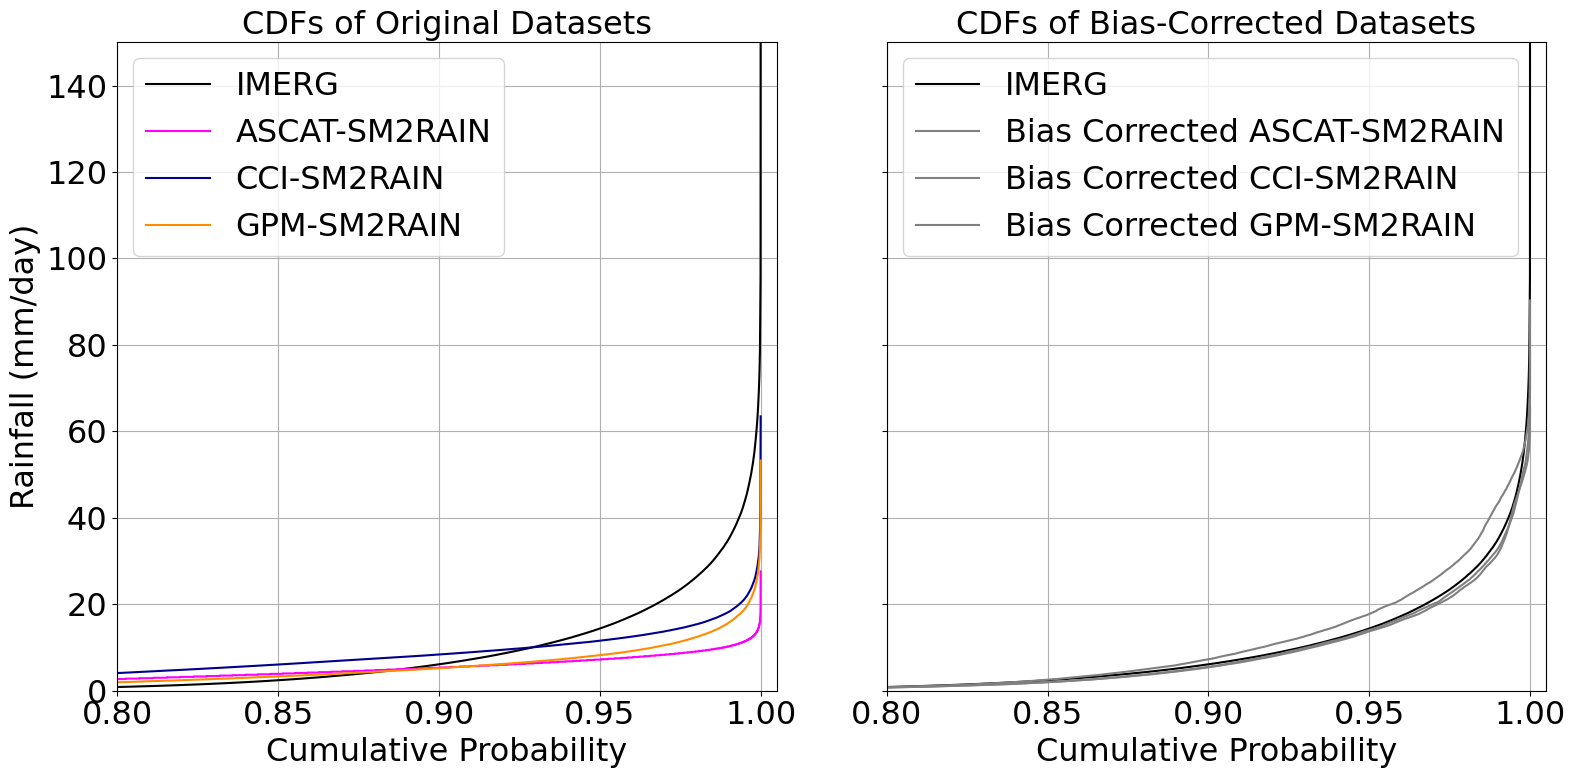

In [309]:
# Prepare datasets for plotting
plt.rcParams.update({'font.size': 14})  # Update font size for larger text
datasets_original = {
    "IMERG": imerg_data.sel(time=slice("2011-01-01", "2015-12-31")).values.flatten(),
    "ASCAT-SM2RAIN": valid_datasets['ASCAT'].values.flatten(),
    "CCI-SM2RAIN": valid_datasets['CCI'].values.flatten(),
    "GPM-SM2RAIN": valid_datasets['GPM'].values.flatten(),
}

datasets_corrected_final = {
    "IMERG": imerg_data.sel(time=slice("2011-01-01", "2015-12-31")).values.flatten(),
    "ASCAT-SM2RAIN_bc": bias_corrected_ascat_valid_final.values.flatten(),
    "CCI-SM2RAIN_bc": bias_corrected_cci_valid_final.values.flatten(),
    "GPM-SM2RAIN_bc": bias_corrected_gpm_valid_final.values.flatten(),
}

colors = {
    "CCI-SM2RAIN": "darkblue",
    "ASCAT-SM2RAIN": "magenta",
    "GPM-SM2RAIN": "darkorange",
    "IMERG": "black",
    "ASCAT-SM2RAIN_bc": "magenta",
    "CCI-SM2RAIN_bc": "darkblue",
    "GPM-SM2RAIN_bc": "darkorange",
}

# Plot the CDFs
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Plot original datasets
for label, data in datasets_original.items():
    data_clean = data[~np.isnan(data)]  # Remove NaN values
    sorted_data, cdf = calculate_cdf(data_clean)
    axes[0].plot(cdf, sorted_data, label=label, color=colors.get(label, "gray"))

axes[0].set_xlim(0.8, 1.005)  # Limit CDF to range 0.8 to 1
axes[0].set_ylim(0, 150)  # Limit y-axis to range 0 to 150 mm/day
axes[0].set_title("CDFs of Original Datasets")
axes[0].set_xlabel("Cumulative Probability")
axes[0].set_ylabel("Rainfall (mm/day)")
axes[0].legend()
axes[0].grid()

# Plot bias-corrected datasets
for label, data in datasets_corrected_q100.items():
    data_clean = data[~np.isnan(data)]  # Remove NaN values
    sorted_data, cdf = calculate_cdf(data_clean)
    axes[1].plot(cdf, sorted_data, label=label, color=colors.get(label, "gray"))

axes[1].set_xlim(0.8, 1.005)  # Limit CDF to range 0.8 to 1
axes[1].set_ylim(0, 150)  # Limit y-axis to range 0 to 150 mm/day
axes[1].set_title("CDFs of Bias-Corrected Datasets")
axes[1].set_xlabel("Cumulative Probability")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


C:\Users\bjoer\AppData\Local\Temp\ipykernel_9512\1102680762.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


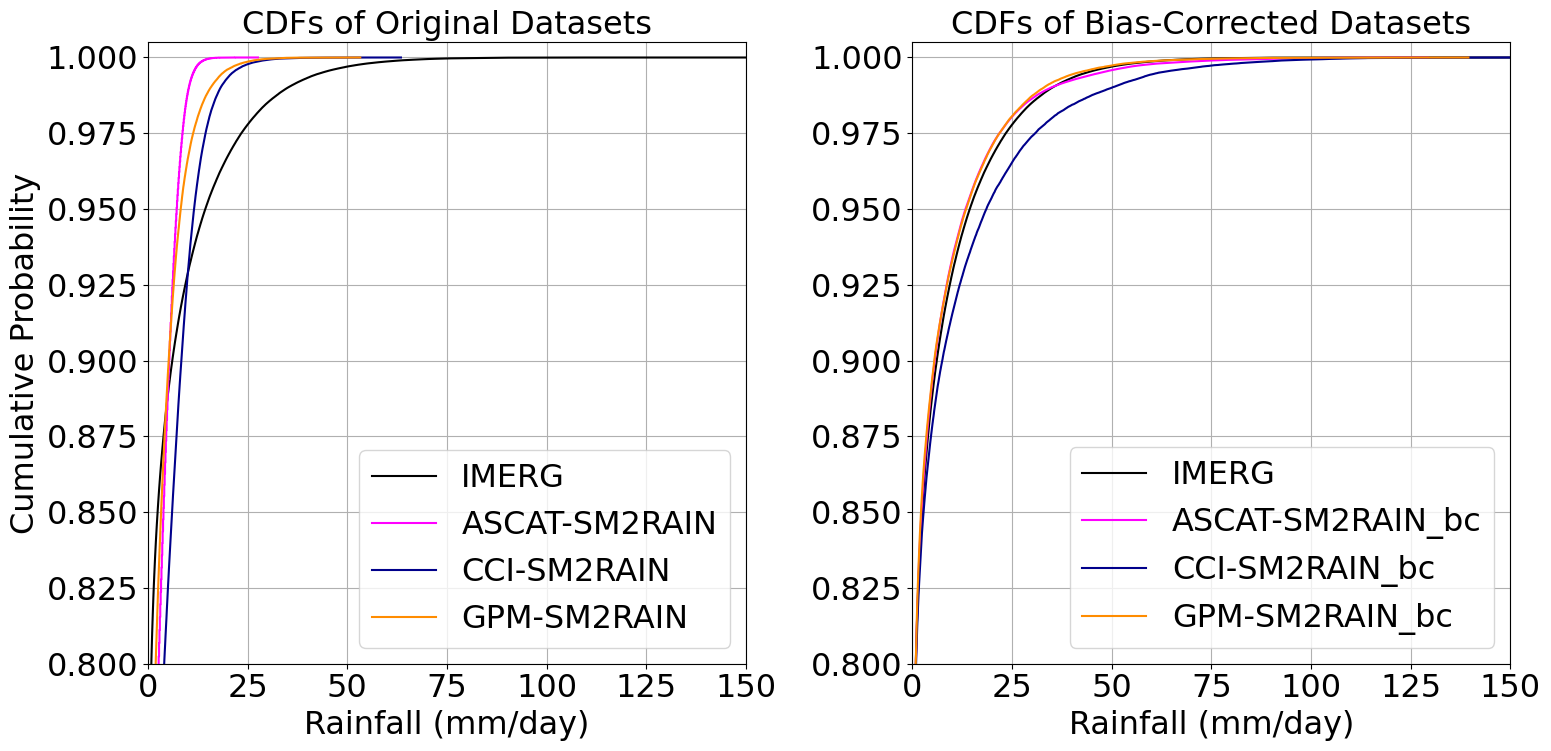

In [310]:
# Update font sizes for larger text
plt.rcParams.update({'font.size': 23, 'axes.titlesize': 23, 'axes.labelsize': 23, 'legend.fontsize': 23, 'xtick.labelsize': 23, 'ytick.labelsize': 23})

# Plot the CDFs
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

# Plot original datasets with flipped axes
for label, data in datasets_original.items():
    data_clean = data[~np.isnan(data)]  # Remove NaN values
    sorted_data, cdf = calculate_cdf(data_clean)
    axes[0].plot(sorted_data, cdf, label=label, color=colors.get(label, "gray"))

axes[0].set_xlim(0, 150)  # Rainfall on x-axis
axes[0].set_ylim(0.8, 1.005)  # CDF on y-axis
axes[0].set_title("CDFs of Original Datasets")
axes[0].set_xlabel("Rainfall (mm/day)")
axes[0].set_ylabel("Cumulative Probability")
axes[0].legend()
axes[0].grid()

# Plot bias-corrected datasets with flipped axes
for label, data in datasets_corrected_final.items():
    data_clean = data[~np.isnan(data)]  # Remove NaN values
    sorted_data, cdf = calculate_cdf(data_clean)
    axes[1].plot(sorted_data, cdf, label=label, color=colors.get(label, "gray"))

axes[1].set_xlim(0, 150)
axes[1].set_ylim(0.8, 1.005)
axes[1].set_title("CDFs of Bias-Corrected Datasets")
axes[1].set_xlabel("Rainfall (mm/day)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


In [95]:
valid_datasets['GPM'] = valid_datasets['GPM'].assign_coords(
    lat=('lat', valid_datasets['GPM'].lat.values),
    lon=('lon', valid_datasets['GPM'].lon.values)
)


In [103]:
valid_datasets['IMERG_GPM'] = valid_datasets['IMERG_GPM'].assign_coords(
    latitude=valid_datasets['IMERG_GPM'].lat,
    longitude=valid_datasets['IMERG_GPM'].lon
)


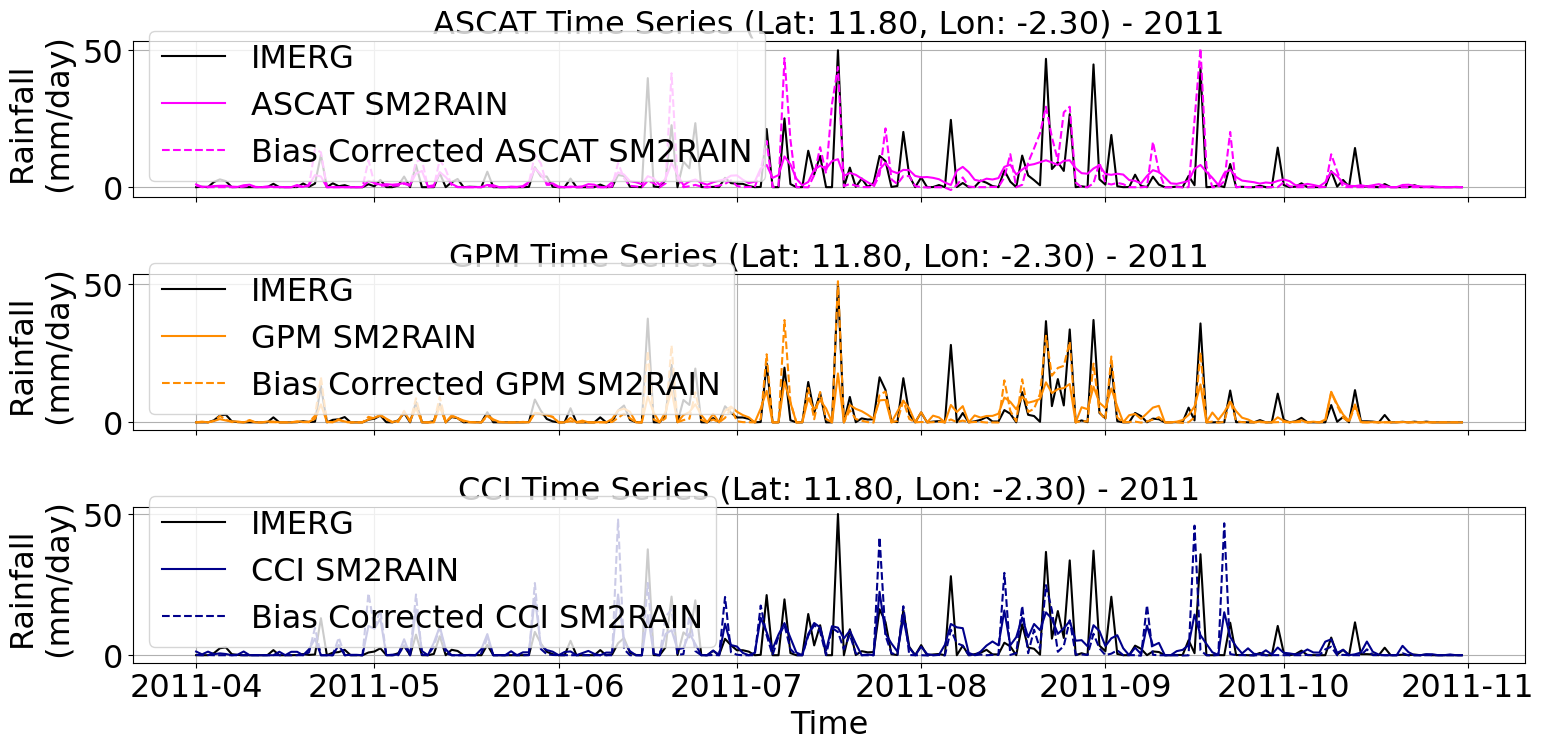

In [313]:
import random
import matplotlib.pyplot as plt

# Randomly sample a point (lat, lon) from the valid_datasets['ASCAT'] coordinates
lat = 11.80
lon = -2.30

# Extract time series for the sampled point
time_series_ascat = valid_datasets['ASCAT'].sel(lat=lat, lon=lon, method="nearest").sel(time=valid_datasets['ASCAT'].time.dt.month.isin(range(4, 11)))
time_series_imerg_ascat = valid_datasets['IMERG_ASCAT'].sel(lat=lat, lon=lon, method="nearest").sel(time=valid_datasets['IMERG_ASCAT'].time.dt.month.isin(range(4, 11)))
time_series_bias_corrected_ascat = bias_corrected_ascat_valid_final.sel(lat=lat, lon=lon, method="nearest").sel(time=bias_corrected_ascat_valid_final.time.dt.month.isin(range(4, 11)))

time_series_gpm = valid_datasets['GPM'].sel(lat=lat, lon=lon, method="nearest").sel(time=valid_datasets['GPM'].time.dt.month.isin(range(4, 11)))
time_series_imerg_gpm = valid_datasets['IMERG_GPM'].sel(latitude=lat, longitude=lon, method="nearest").sel(time=valid_datasets['IMERG_GPM'].time.dt.month.isin(range(4, 11)))
time_series_bias_corrected_gpm = bias_corrected_gpm_valid_final.sel(lat=lat, lon=lon, method="nearest").sel(time=bias_corrected_gpm_valid_final.time.dt.month.isin(range(4, 11)))

time_series_cci = valid_datasets['CCI'].sel(lat=lat, lon=lon, method="nearest").sel(time=valid_datasets['CCI'].time.dt.month.isin(range(4, 11)))
time_series_imerg_cci = valid_datasets['IMERG_CCI'].sel(lat=lat, lon=lon, method="nearest").sel(time=valid_datasets['IMERG_CCI'].time.dt.month.isin(range(4, 11)))
time_series_bias_corrected_cci = bias_corrected_cci_valid_final.sel(lat=lat, lon=lon, method="nearest").sel(time=bias_corrected_cci_valid_final.time.dt.month.isin(range(4, 11)))

# Extract the first year of data
time_series_ascat_first_year = time_series_ascat.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))
time_series_imerg_ascat_first_year = time_series_imerg_ascat.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))
time_series_bias_corrected_ascat_first_year = time_series_bias_corrected_ascat.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))

time_series_gpm_first_year = time_series_gpm.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))
time_series_imerg_gpm_first_year = time_series_imerg_gpm.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))
time_series_bias_corrected_gpm_first_year = time_series_bias_corrected_gpm.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))

time_series_cci_first_year = time_series_cci.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))
time_series_imerg_cci_first_year = time_series_imerg_cci.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))
time_series_bias_corrected_cci_first_year = time_series_bias_corrected_cci.sel(time=slice(valid_start, f"{valid_start[:4]}-12-31"))

# Plot the time series
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

# ASCAT
axes[0].plot(time_series_imerg_ascat_first_year.time, time_series_imerg_ascat_first_year, label="IMERG", color="black")
axes[0].plot(time_series_ascat_first_year.time, time_series_ascat_first_year, label="ASCAT SM2RAIN", color="magenta")
axes[0].plot(time_series_bias_corrected_ascat_first_year.time, time_series_bias_corrected_ascat_first_year, label="Bias Corrected ASCAT SM2RAIN", color="magenta", linestyle='--')
axes[0].set_title(f"ASCAT Time Series (Lat: {lat:.2f}, Lon: {lon:.2f}) - 2011")
axes[0].set_ylabel("Rainfall \n (mm/day)")
axes[0].legend()
axes[0].grid()

# GPM
axes[1].plot(time_series_imerg_gpm_first_year.time, time_series_imerg_gpm_first_year, label="IMERG", color="black")
axes[1].plot(time_series_gpm_first_year.time, time_series_gpm_first_year, label="GPM SM2RAIN", color="darkorange")
axes[1].plot(time_series_bias_corrected_gpm_first_year.time, time_series_bias_corrected_gpm_first_year, label="Bias Corrected GPM SM2RAIN", color="darkorange", linestyle='--')
axes[1].set_title(f"GPM Time Series (Lat: {lat:.2f}, Lon: {lon:.2f}) - 2011")
axes[1].set_ylabel("Rainfall \n (mm/day)")
axes[1].legend()
axes[1].grid()

# CCI
axes[2].plot(time_series_imerg_cci_first_year.time, time_series_imerg_cci_first_year, label="IMERG", color="black")
axes[2].plot(time_series_cci_first_year.time, time_series_cci_first_year, label="CCI SM2RAIN", color="darkblue")
axes[2].plot(time_series_bias_corrected_cci_first_year.time, time_series_bias_corrected_cci_first_year, label="Bias Corrected CCI SM2RAIN", color="darkblue", linestyle='--')
axes[2].set_title(f"CCI Time Series (Lat: {lat:.2f}, Lon: {lon:.2f}) - 2011")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Rainfall \n (mm/day)")
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

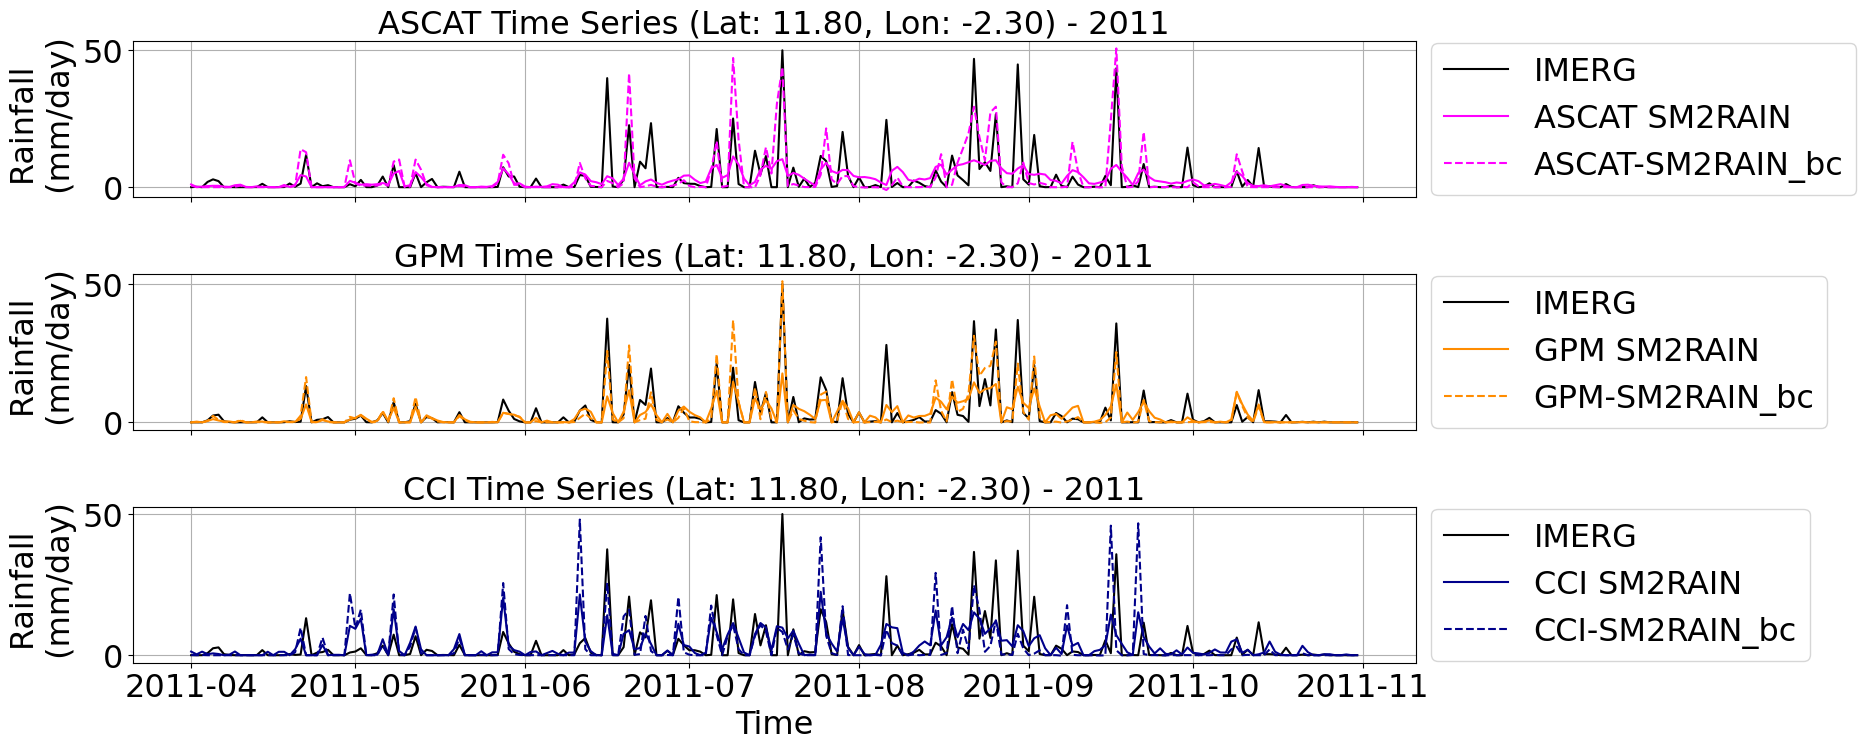

In [334]:
plt.rcParams.update({'font.size': 23, 'axes.titlesize': 23, 'axes.labelsize': 23, 'legend.fontsize': 23, 'xtick.labelsize': 23, 'ytick.labelsize': 23})

# Plot the time series
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

# ASCAT
axes[0].plot(time_series_imerg_ascat_first_year.time, time_series_imerg_ascat_first_year, label="IMERG", color="black")
axes[0].plot(time_series_ascat_first_year.time, time_series_ascat_first_year, label="ASCAT SM2RAIN", color="magenta")
axes[0].plot(time_series_bias_corrected_ascat_first_year.time, time_series_bias_corrected_ascat_first_year, label="ASCAT-SM2RAIN_bc", color="magenta", linestyle='--')
axes[0].set_title(f"ASCAT Time Series (Lat: {lat:.2f}, Lon: {lon:.2f}) - 2011")
axes[0].set_ylabel("Rainfall \n (mm/day)")
axes[0].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
axes[0].grid()

# GPM
axes[1].plot(time_series_imerg_gpm_first_year.time, time_series_imerg_gpm_first_year, label="IMERG", color="black")
axes[1].plot(time_series_gpm_first_year.time, time_series_gpm_first_year, label="GPM SM2RAIN", color="darkorange")
axes[1].plot(time_series_bias_corrected_gpm_first_year.time, time_series_bias_corrected_gpm_first_year, label="GPM-SM2RAIN_bc", color="darkorange", linestyle='--')
axes[1].set_title(f"GPM Time Series (Lat: {lat:.2f}, Lon: {lon:.2f}) - 2011")
axes[1].set_ylabel("Rainfall \n (mm/day)")
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
axes[1].grid()

# CCI
axes[2].plot(time_series_imerg_cci_first_year.time, time_series_imerg_cci_first_year, label="IMERG", color="black")
axes[2].plot(time_series_cci_first_year.time, time_series_cci_first_year, label="CCI SM2RAIN", color="darkblue")
axes[2].plot(time_series_bias_corrected_cci_first_year.time, time_series_bias_corrected_cci_first_year, label="CCI-SM2RAIN_bc", color="darkblue", linestyle='--')
axes[2].set_title(f"CCI Time Series (Lat: {lat:.2f}, Lon: {lon:.2f}) - 2011")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Rainfall \n (mm/day)")
axes[2].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
axes[2].grid()

plt.tight_layout()
plt.subplots_adjust(right=0.8)  # Leave space for legends
plt.show()


In [94]:
print(valid_datasets['GPM'].coords)


Coordinates:
    lon      (lon) float32 64B -2.875 -2.625 -2.375 -2.125 ... 0.375 0.625 0.875
    lat      (lat) float32 48B 11.12 11.38 11.62 11.88 ... 13.38 13.62 13.88
  * time     (time) datetime64[ns] 15kB 2011-01-01 2011-01-02 ... 2015-12-31


In [44]:
def calculate_pod(h, m):
    """
    Calculate Probability of Detection (POD).
    POD = h / (h + m)
    """
    return h / (h + m) if (h + m) > 0 else 0

def calculate_far(f, h):
    """
    Calculate False Alarm Ratio (FAR).
    FAR = f / (h + f)
    """
    return f / (h + f) if (h + f) > 0 else np.nan

def calculate_csi(h, m, f):
    """
    Calculate Threat Score (TS) or Critical Success Index (CSI).
    CSI = h / (h + m + f)
    """
    return h / (h + m + f) if (h + m + f) > 0 else 0

def process_precipitation_data(observed_data, simulated_data, threshold):
    """
    Process observed and simulated precipitation data to calculate metrics.

    Parameters:
        observed_data (np.array): Numpy array of observed precipitation data.
        simulated_data (np.array): Numpy array of simulated precipitation data.
        threshold (float): Threshold for rainfall events (e.g., 0.1 mm/day).

    Returns:
        dict: Dictionary with POD, FAR, and CSI values.
    """
    # Binary mask for rainfall events
    obs_events = (observed_data >= threshold)
    sim_events = (simulated_data >= threshold)
    
    # Calculate hit (h), miss (m), and false alarm (f)
    h = np.sum(obs_events & sim_events)  # Hit: observed and simulated
    m = np.sum(obs_events & ~sim_events) # Miss: observed but not simulated
    f = np.sum(~obs_events & sim_events) # False alarm: simulated but not observed
    
    # Calculate metrics
    pod = calculate_pod(h, m)
    far = calculate_far(f, h)
    csi = calculate_csi(h, m, f)
    
    return {"POD": pod, "FAR": far, "CSI": csi}

In [246]:
# Define thresholds range
thresholds = np.arange(1, 51, 1)

# Initialize lists to store results
results_list = []

# Loop through each threshold
for threshold in thresholds:
    metrics_cci = process_precipitation_data(valid_datasets['IMERG_CCI'].values, valid_datasets['CCI'].values, threshold)
    metrics_cci_bias_corrected = process_precipitation_data(valid_datasets['IMERG_CCI'].values.transpose(2, 1, 0), bias_corrected_cci_valid_final.values, threshold)

    metrics_ascat = process_precipitation_data(valid_datasets['IMERG_ASCAT'].values, valid_datasets['ASCAT'].values, threshold)
    metrics_ascat_bias_corrected = process_precipitation_data(valid_datasets['IMERG_ASCAT'].values.transpose(2, 1, 0), bias_corrected_ascat_valid_final.values, threshold)

    metrics_gpm = process_precipitation_data(valid_datasets['IMERG_GPM'].values, valid_datasets['GPM'].values, threshold)
    metrics_gpm_bias_corrected = process_precipitation_data(valid_datasets['IMERG_GPM'].values.transpose(2, 1, 0), bias_corrected_gpm_valid_final.values, threshold)
    
    # Append results to the list
    results_list.append({
        "Threshold": threshold,
        "POD_CCI": metrics_cci["POD"],
        "FAR_CCI": metrics_cci["FAR"],
        "CSI_CCI": metrics_cci["CSI"],
        "POD_BiasCorrected_CCI": metrics_cci_bias_corrected["POD"],
        "FAR_BiasCorrected_CCI": metrics_cci_bias_corrected["FAR"],
        "CSI_BiasCorrected_CCI": metrics_cci_bias_corrected["CSI"],
        "POD_ASCAT": metrics_ascat["POD"],
        "FAR_ASCAT": metrics_ascat["FAR"],
        "CSI_ASCAT": metrics_ascat["CSI"],
        "POD_BiasCorrected_ASCAT": metrics_ascat_bias_corrected["POD"],
        "FAR_BiasCorrected_ASCAT": metrics_ascat_bias_corrected["FAR"],
        "CSI_BiasCorrected_ASCAT": metrics_ascat_bias_corrected["CSI"],
        "POD_GPM": metrics_gpm["POD"],
        "FAR_GPM": metrics_gpm["FAR"],
        "CSI_GPM": metrics_gpm["CSI"],
        "POD_BiasCorrected_GPM": metrics_gpm_bias_corrected["POD"],
        "FAR_BiasCorrected_GPM": metrics_gpm_bias_corrected["FAR"],
        "CSI_BiasCorrected_GPM": metrics_gpm_bias_corrected["CSI"]
    })


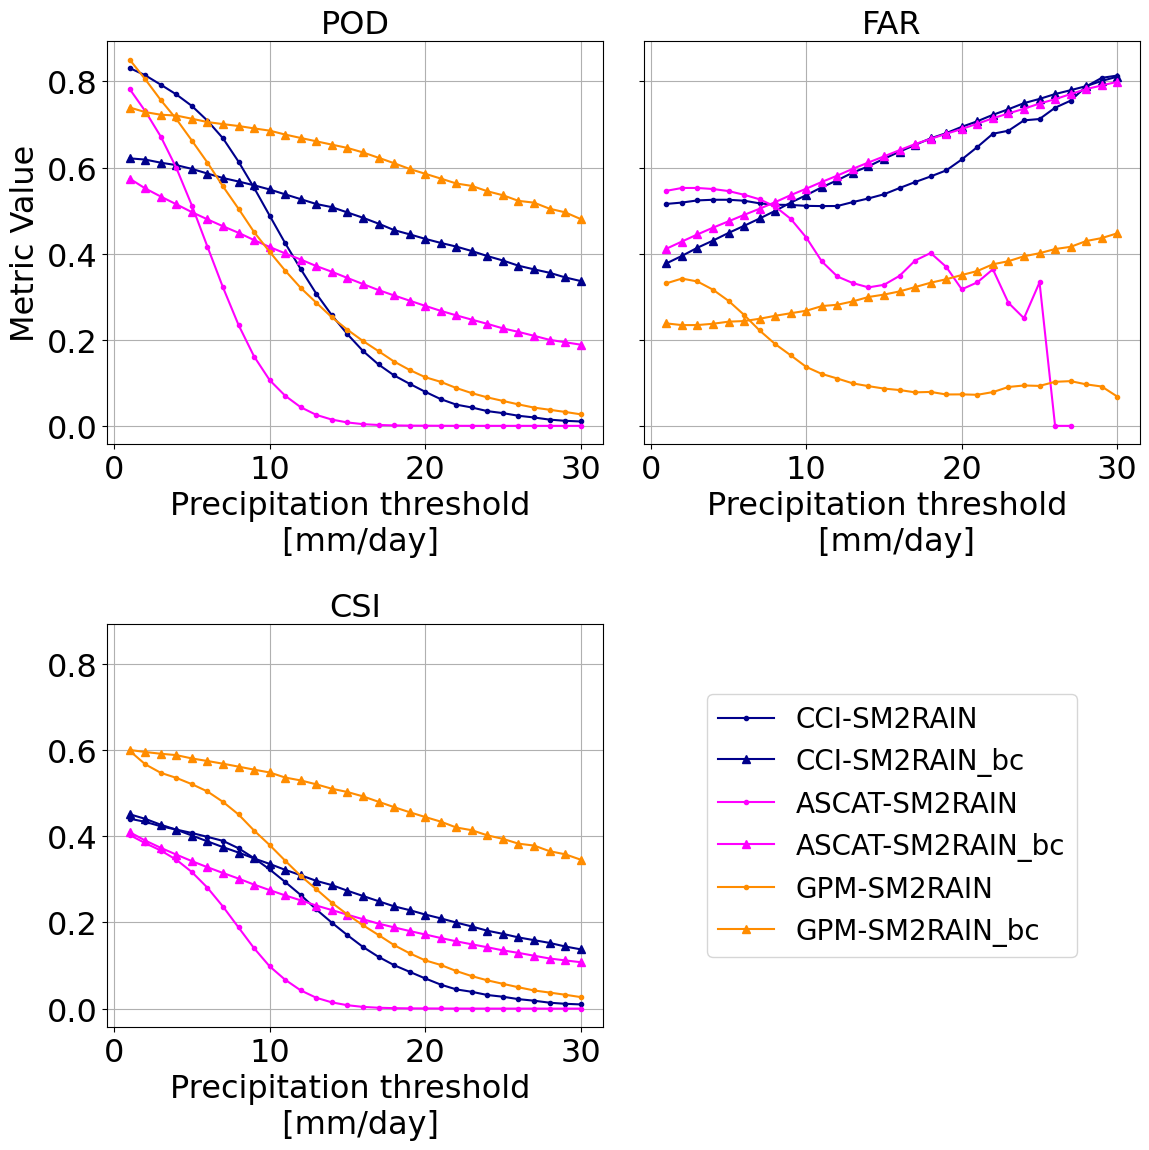

In [332]:
import matplotlib.pyplot as plt

# Create 2x2 grid layout
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True)

# Define metrics and flatten axes
metrics = ["POD", "FAR", "CSI"]
axes_flat = axes.flatten()

# Collect legend handles once
legend_handles = []
legend_labels = []

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    for product in products:
        h1, = ax.plot(results_df["Threshold"], results_df[f"{metric}_{product}"],
                      color=colors[product], linestyle='-', marker='o', markersize=3)
        h2, = ax.plot(results_df["Threshold"], results_df[f"{metric}_BiasCorrected_{product}"],
                      color=colors[product], linestyle='-', marker='^', markersize=6)

        # Collect handles once
        if i == 0:
            legend_handles.extend([h1, h2])
            legend_labels.extend([f"{product}-SM2RAIN", f"{product}-SM2RAIN_bc"])

    ax.set_title(metric)
    ax.set_xlabel("Precipitation threshold \n [mm/day]")
    if i == 0:
        ax.set_ylabel("Metric Value")
    ax.grid()

# Use the 4th plot space (bottom-right) for legend
axes_flat[3].axis('off')  # Turn off plot
axes_flat[3].legend(
    legend_handles,
    legend_labels,
    loc='center',
    ncol=1,  # <- One column legend
    fontsize=20,
    frameon=True
)
# Clean layout
plt.tight_layout()
plt.show()


In [350]:
def calculate_contingency_table_xr(reference, simulated, simulated_bias_corrected, threshold=20):
    """
    Calculate the contingency table (as percentages) for precipitation (thresholded at 10mm)
    using xarray DataArrays, and return results as a DataFrame.
    
    Args:
        reference (xarray.DataArray): Reference precipitation data (observed values).
        simulated (xarray.DataArray): Simulated precipitation data (original).
        simulated_bias_corrected (xarray.DataArray): Simulated precipitation data (bias-corrected).
        threshold (float): Precipitation threshold in mm (default is 10mm).
    
    Returns:
        pd.DataFrame: Contingency table (TP, FP, TN, FN) as percentages for both original and bias-corrected fields.
    """
    
    # Create binary arrays where True (1) is above threshold, False (0) is below threshold
    reference_binary = reference >= threshold
    simulated_binary = simulated >= threshold
    simulated_bias_corrected_binary = simulated_bias_corrected >= threshold
    
    # Function to calculate TP, FP, TN, FN for a binary comparison and return percentages
    def contingency_table(binary_ref, binary_sim):
        TP = np.sum((binary_ref == 1) & (binary_sim == 1))  # True Positive
        FP = np.sum((binary_ref == 0) & (binary_sim == 1))  # False Positive
        TN = np.sum((binary_ref == 0) & (binary_sim == 0))  # True Negative
        FN = np.sum((binary_ref == 1) & (binary_sim == 0))  # False Negative
        total = binary_ref.size
        
        # Convert counts to percentages
        TP_percent = (TP / total) * 100
        FP_percent = (FP / total) * 100
        TN_percent = (TN / total) * 100
        FN_percent = (FN / total) * 100
        
        return TP_percent, FP_percent, TN_percent, FN_percent
    
    # Calculate contingency tables for original and bias-corrected datasets
    TP_orig, FP_orig, TN_orig, FN_orig = contingency_table(reference_binary.values, simulated_binary.values)
    TP_bc, FP_bc, TN_bc, FN_bc = contingency_table(reference_binary.values, simulated_bias_corrected_binary.values)
    
    # Prepare results as a dictionary
    results = {
        "Metric": ["TP", "FP", "TN", "FN"],
        "Original (Uncorrected)": [TP_orig, FP_orig, TN_orig, FN_orig],
        "Bias-Corrected": [TP_bc, FP_bc, TN_bc, FN_bc]
    }
    
    # Convert the results to a pandas DataFrame
    df_results = pd.DataFrame(results)
    df_results.set_index("Metric", inplace=True)
    
    return df_results

In [351]:
con_table_cci = calculate_contingency_table_xr(valid_datasets['IMERG_CCI'], valid_datasets['CCI'], bias_corrected_cci_valid_final.transpose('time', 'lat', 'lon'), threshold=20)

In [352]:
con_table_cci

,Original (Uncorrected),Bias-Corrected
Metric,,
TP,0.255568,1.402485
FP,0.414727,3.189177
TN,96.356449,93.581998
FN,2.973257,1.826339


In [293]:
# Define the threshold
threshold = 20

# Calculate POD for each dataset before and after bias correction
pod_before = [
    process_precipitation_data(valid_datasets['IMERG_ASCAT'].values, valid_datasets['ASCAT'].values, threshold)["POD"],
    process_precipitation_data(valid_datasets['IMERG_CCI'].values, valid_datasets['CCI'].values, threshold)["POD"],
    process_precipitation_data(valid_datasets['IMERG_GPM'].values, valid_datasets['GPM'].values, threshold)["POD"]
]

pod_after = [
    process_precipitation_data(valid_datasets['IMERG_ASCAT'].values, bias_corrected_ascat_valid_final.values.transpose(2, 1, 0), threshold)["POD"],
    process_precipitation_data(valid_datasets['IMERG_CCI'].values, bias_corrected_cci_valid_final.values.transpose(2, 1, 0), threshold)["POD"],
    process_precipitation_data(valid_datasets['IMERG_GPM'].values, bias_corrected_gpm_valid_final.values.transpose(2, 1, 0), threshold)["POD"]
]

# Calculate the mean POD before and after bias correction
mean_pod_before = np.mean(pod_before)
mean_pod_after = np.mean(pod_after)

print(f"Mean POD before bias correction: {mean_pod_before:.4f}")
print(f"Mean POD after bias correction: {mean_pod_after:.4f}")

Mean POD before bias correction: 0.0642
Mean POD after bias correction: 0.4329


In [272]:
def calculate_metrics_per_gridpoint(reference, dataset):
    """
    Calculate R value, PBIAS, and RMSE for each grid point between a reference dataset and another dataset.

    Parameters:
        reference (xarray.DataArray): Reference dataset (e.g., IMERG).
        dataset (xarray.DataArray): Dataset to compare against the reference.

    Returns:
        dict: Dictionary containing 2D arrays for R value, PBIAS, and RMSE.
    """
    # Ensure the datasets have the same dimensions
    assert reference.shape == dataset.shape, "Reference and dataset must have the same shape."

    # Initialize empty arrays for the metrics
    r_values = np.full((reference.lat.size, reference.lon.size), np.nan)
    pbias_values = np.full((reference.lat.size, reference.lon.size), np.nan)
    rmse_values = np.full((reference.lat.size, reference.lon.size), np.nan)

    # Iterate over each grid point
    for i in range(reference.lat.size):
        for j in range(reference.lon.size):
            # Extract time series for the current grid point
            ref_values = reference[:, i, j].values
            data_values = dataset[:, i, j].values

            # Mask NaN values
            mask = ~np.isnan(ref_values) & ~np.isnan(data_values)
            ref_values = ref_values[mask]
            data_values = data_values[mask]

            # Skip if no valid data
            if ref_values.size == 0 or data_values.size == 0:
                continue

            # Calculate R value (correlation coefficient)
            r_values[i, j] = np.corrcoef(ref_values, data_values)[0, 1]

            # Calculate PBIAS (percent bias)
            pbias_values[i, j] = 100 * np.sum(data_values - ref_values) / np.sum(ref_values)

            # Calculate RMSE (root mean square error)
            rmse_values[i, j] = np.sqrt(np.mean((data_values - ref_values) ** 2))

    return {"R": r_values, "PBIAS": pbias_values, "RMSE": rmse_values}


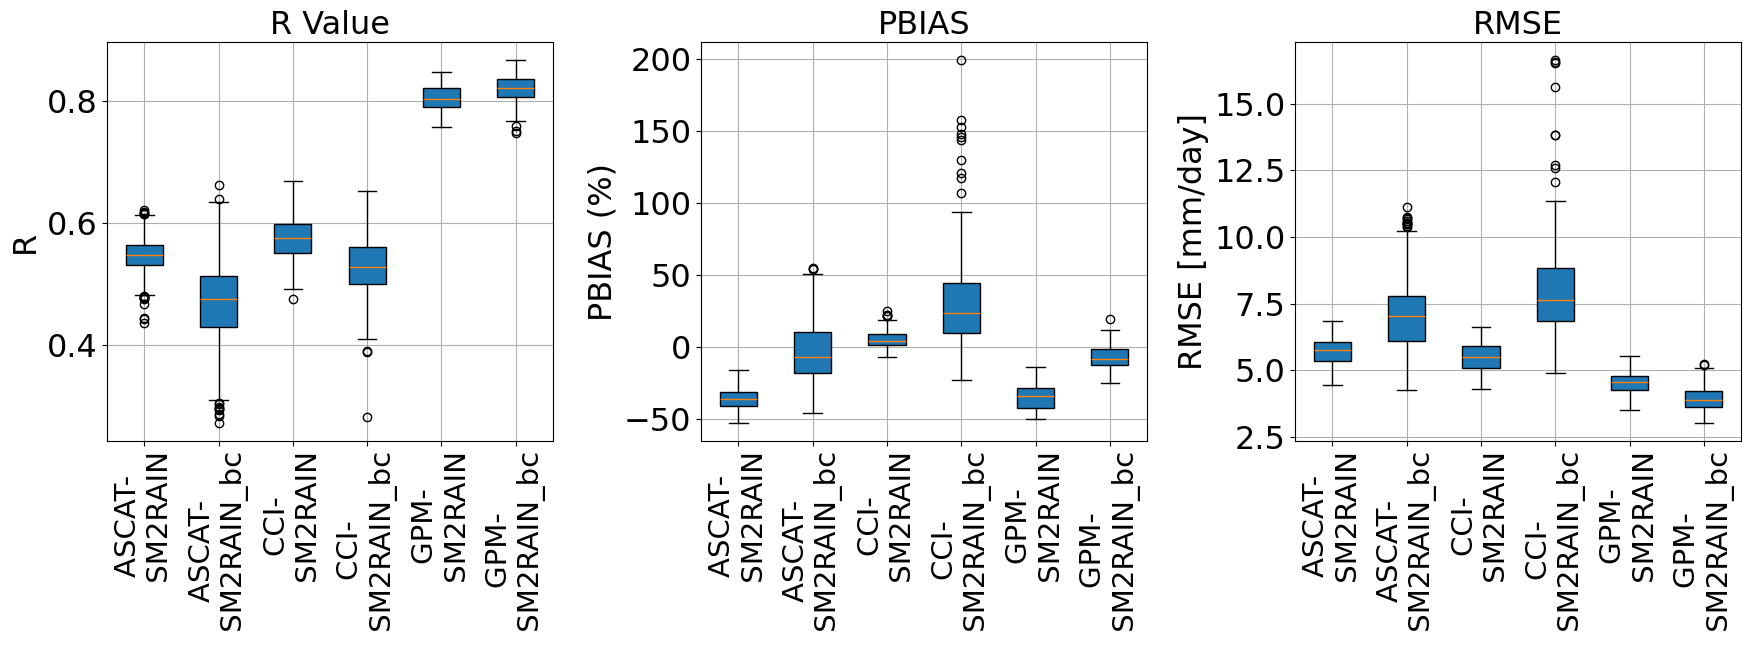

In [341]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize lists to store cleaned, flattened metrics
r_values = []
pbias_values = []
rmse_values = []

# Define dataset-label pairs (simplified labels!)
datasets = {
    "ASCAT- \n SM2RAIN": (valid_datasets['ASCAT'], valid_datasets['IMERG_ASCAT']),
    "ASCAT- \n SM2RAIN_bc": (bias_corrected_ascat_valid_final.transpose('time', 'lat', 'lon'), valid_datasets['IMERG_ASCAT']),
    "CCI- \n SM2RAIN": (valid_datasets['CCI'], valid_datasets['IMERG_CCI']),
    "CCI- \n SM2RAIN_bc": (bias_corrected_cci_valid_final.transpose('time', 'lat', 'lon'), valid_datasets['IMERG_CCI']),
    "GPM- \n SM2RAIN": (valid_datasets['GPM'], valid_datasets['IMERG_GPM']),
    "GPM- \n SM2RAIN_bc": (bias_corrected_gpm_valid_final.transpose('time', 'lat', 'lon'), valid_datasets['IMERG_GPM']),
}

# Go through datasets
for name, (dataset, reference) in datasets.items():
    metrics = calculate_metrics_per_gridpoint(reference, dataset)

    # Flatten and drop NaNs
    r_flat = metrics["R"].ravel()
    pbias_flat = metrics["PBIAS"].ravel()
    rmse_flat = metrics["RMSE"].ravel()

    r_values.append(r_flat[~np.isnan(r_flat)])
    pbias_values.append(pbias_flat[~np.isnan(pbias_flat)])
    rmse_values.append(rmse_flat[~np.isnan(rmse_flat)])

# Labels for x-axis
labels = list(datasets.keys())

# Create boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Define a helper function to style each plot
def format_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=23)
    ax.set_ylabel(ylabel, fontsize=23)
    ax.set_xticklabels(labels, rotation=90, fontsize=21)
    ax.grid()

# R value boxplot
axes[0].boxplot(r_values, patch_artist=True)
format_ax(axes[0], "R Value", "R")

# PBIAS boxplot
axes[1].boxplot(pbias_values, patch_artist=True)
format_ax(axes[1], "PBIAS", "PBIAS (%)")

# RMSE boxplot
axes[2].boxplot(rmse_values, patch_artist=True)
format_ax(axes[2], "RMSE", "RMSE [mm/day]")

plt.tight_layout()
plt.show()


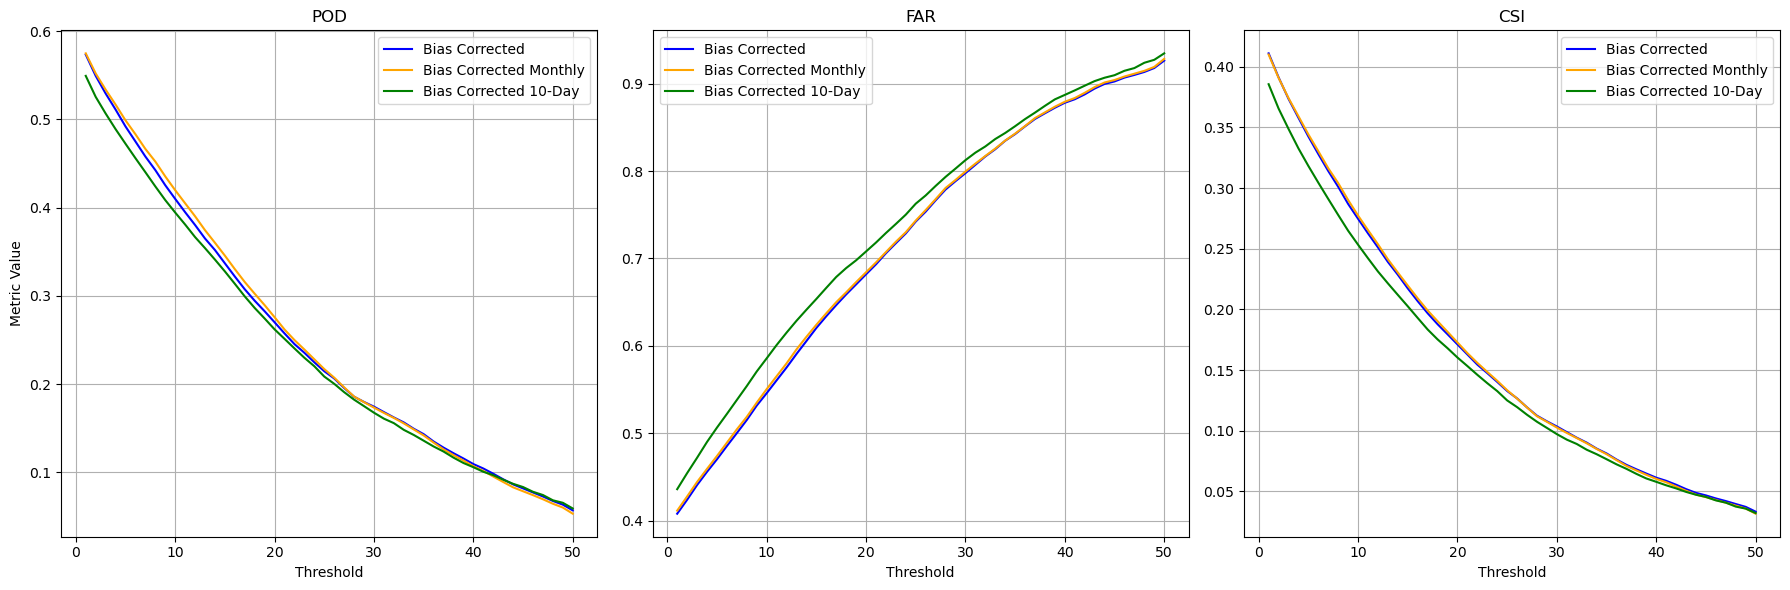

In [ ]:
# Define thresholds range
thresholds = np.arange(1, 51, 1)

# Initialize lists to store results
metrics_bias_corrected_list = []
metrics_bias_corrected_monthly_list = []
metrics_bias_corrected_10day_list = []

# Loop through each threshold
for threshold in thresholds:
    # Calculate metrics for bias_corrected_ascat_valid
    metrics_bias_corrected = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid.values.transpose(2, 0, 1),
        threshold
    )
    metrics_bias_corrected_list.append(metrics_bias_corrected)

    # Calculate metrics for bias_corrected_ascat_valid_monthly
    metrics_bias_corrected_monthly = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid_monthly.values.transpose(2, 0, 1),
        threshold
    )
    metrics_bias_corrected_monthly_list.append(metrics_bias_corrected_monthly)

    # Calculate metrics for bias_corrected_ascat_valid_10day
    metrics_bias_corrected_10day = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid_10day.values.transpose(2, 0, 1),
        threshold
    )
    metrics_bias_corrected_10day_list.append(metrics_bias_corrected_10day)

# Convert results to DataFrame for easier plotting
metrics_df = pd.DataFrame(metrics_bias_corrected_list)
metrics_monthly_df = pd.DataFrame(metrics_bias_corrected_monthly_list)
metrics_10day_df = pd.DataFrame(metrics_bias_corrected_10day_list)

# Add thresholds to DataFrames
metrics_df['Threshold'] = thresholds
metrics_monthly_df['Threshold'] = thresholds
metrics_10day_df['Threshold'] = thresholds

# Plot the metrics
plt.figure(figsize=(18, 6))

# Plot POD
plt.subplot(1, 3, 1)
plt.plot(metrics_df['Threshold'], metrics_df['POD'], label="Bias Corrected", color="blue")
plt.plot(metrics_monthly_df['Threshold'], metrics_monthly_df['POD'], label="Bias Corrected Monthly", color="orange")
plt.plot(metrics_10day_df['Threshold'], metrics_10day_df['POD'], label="Bias Corrected 10-Day", color="green")
plt.title("POD")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.grid()

# Plot FAR
plt.subplot(1, 3, 2)
plt.plot(metrics_df['Threshold'], metrics_df['FAR'], label="Bias Corrected", color="blue")
plt.plot(metrics_monthly_df['Threshold'], metrics_monthly_df['FAR'], label="Bias Corrected Monthly", color="orange")
plt.plot(metrics_10day_df['Threshold'], metrics_10day_df['FAR'], label="Bias Corrected 10-Day", color="green")
plt.title("FAR")
plt.xlabel("Threshold")
plt.legend()
plt.grid()

# Plot CSI
plt.subplot(1, 3, 3)
plt.plot(metrics_df['Threshold'], metrics_df['CSI'], label="Bias Corrected", color="blue")
plt.plot(metrics_monthly_df['Threshold'], metrics_monthly_df['CSI'], label="Bias Corrected Monthly", color="orange")
plt.plot(metrics_10day_df['Threshold'], metrics_10day_df['CSI'], label="Bias Corrected 10-Day", color="green")
plt.title("CSI")
plt.xlabel("Threshold")
plt.legend()
plt.grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

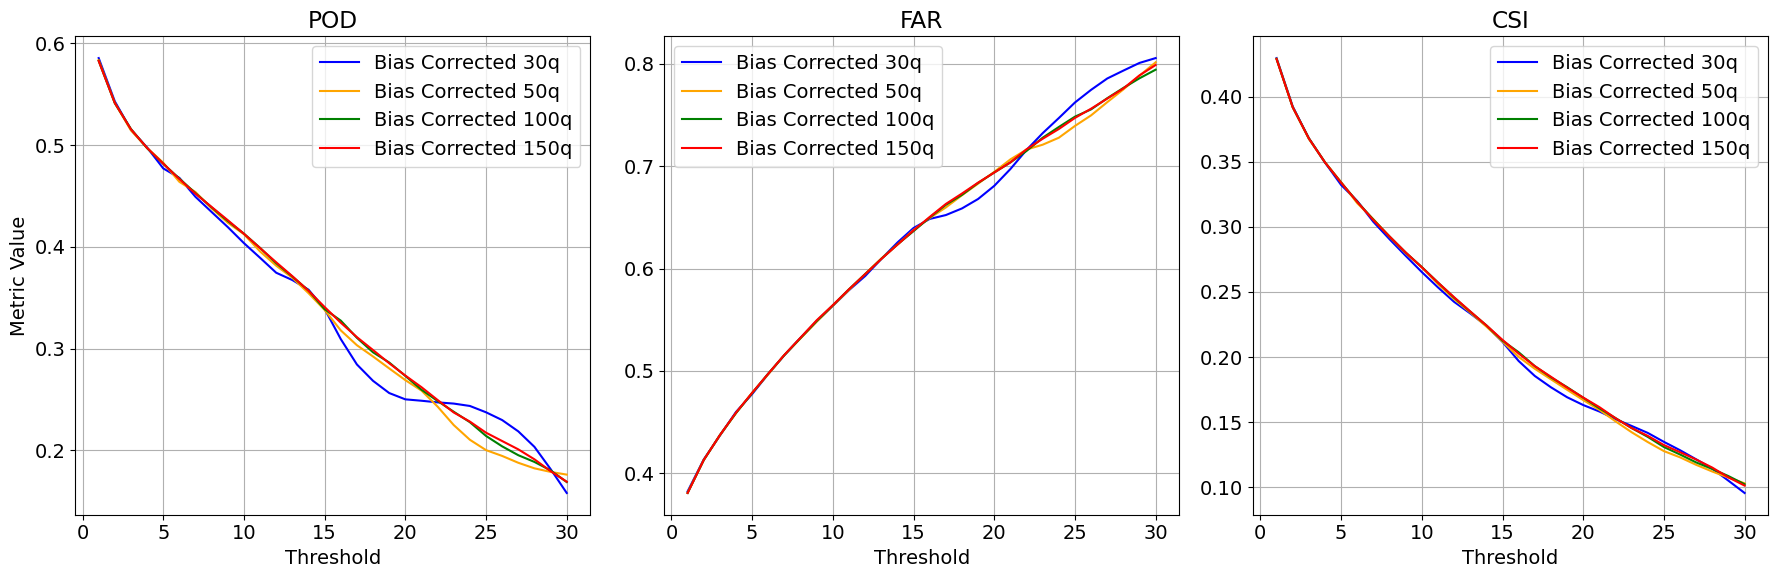

In [85]:
# Define thresholds range
thresholds = np.arange(1, 31, 1)

# Initialize lists to store results
metrics_bias_corrected_list = []
metrics_bias_corrected_50q_list = []
metrics_bias_corrected_100q_list = []
metrics_bias_corrected_150q_list = []

# Loop through each threshold
for threshold in thresholds:
    # Calculate metrics for bias_corrected_ascat_valid
    metrics_bias_corrected = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid.values.transpose(2, 1, 0),
        threshold
    )
    metrics_bias_corrected_list.append(metrics_bias_corrected)

    # Calculate metrics for bias_corrected_ascat_valid_50q
    metrics_bias_corrected_50q = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid_50q.values.transpose(2, 1, 0),
        threshold
    )
    metrics_bias_corrected_50q_list.append(metrics_bias_corrected_50q)

    # Calculate metrics for bias_corrected_ascat_valid_100q
    metrics_bias_corrected_100q = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid_100q.values.transpose(2, 1, 0),
        threshold
    )
    metrics_bias_corrected_100q_list.append(metrics_bias_corrected_100q)

    # Calculate metrics for bias_corrected_ascat_valid_150q
    metrics_bias_corrected_150q = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid_150q.values.transpose(2, 1, 0),
        threshold
    )
    metrics_bias_corrected_150q_list.append(metrics_bias_corrected_150q)

# Convert results to DataFrame for easier plotting
metrics_df = pd.DataFrame(metrics_bias_corrected_list)
metrics_50q_df = pd.DataFrame(metrics_bias_corrected_50q_list)
metrics_100q_df = pd.DataFrame(metrics_bias_corrected_100q_list)
metrics_150q_df = pd.DataFrame(metrics_bias_corrected_150q_list)

# Add thresholds to DataFrames
metrics_df['Threshold'] = thresholds
metrics_50q_df['Threshold'] = thresholds
metrics_100q_df['Threshold'] = thresholds
metrics_150q_df['Threshold'] = thresholds

# Plot the metrics
plt.figure(figsize=(18, 6))

# Plot POD
plt.subplot(1, 3, 1)
plt.plot(metrics_df['Threshold'], metrics_df['POD'], label="Bias Corrected 30q", color="blue")
plt.plot(metrics_50q_df['Threshold'], metrics_50q_df['POD'], label="Bias Corrected 50q", color="orange")
plt.plot(metrics_100q_df['Threshold'], metrics_100q_df['POD'], label="Bias Corrected 100q", color="green")
plt.plot(metrics_150q_df['Threshold'], metrics_150q_df['POD'], label="Bias Corrected 150q", color="red")
plt.title("POD")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.grid()

# Plot FAR
plt.subplot(1, 3, 2)
plt.plot(metrics_df['Threshold'], metrics_df['FAR'], label="Bias Corrected 30q", color="blue")
plt.plot(metrics_50q_df['Threshold'], metrics_50q_df['FAR'], label="Bias Corrected 50q", color="orange")
plt.plot(metrics_100q_df['Threshold'], metrics_100q_df['FAR'], label="Bias Corrected 100q", color="green")
plt.plot(metrics_150q_df['Threshold'], metrics_150q_df['FAR'], label="Bias Corrected 150q", color="red")
plt.title("FAR")
plt.xlabel("Threshold")
plt.legend()
plt.grid()

# Plot CSI
plt.subplot(1, 3, 3)
plt.plot(metrics_df['Threshold'], metrics_df['CSI'], label="Bias Corrected 30q", color="blue")
plt.plot(metrics_50q_df['Threshold'], metrics_50q_df['CSI'], label="Bias Corrected 50q", color="orange")
plt.plot(metrics_100q_df['Threshold'], metrics_100q_df['CSI'], label="Bias Corrected 100q", color="green")
plt.plot(metrics_150q_df['Threshold'], metrics_150q_df['CSI'], label="Bias Corrected 150q", color="red")
plt.title("CSI")
plt.xlabel("Threshold")
plt.legend()
plt.grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()




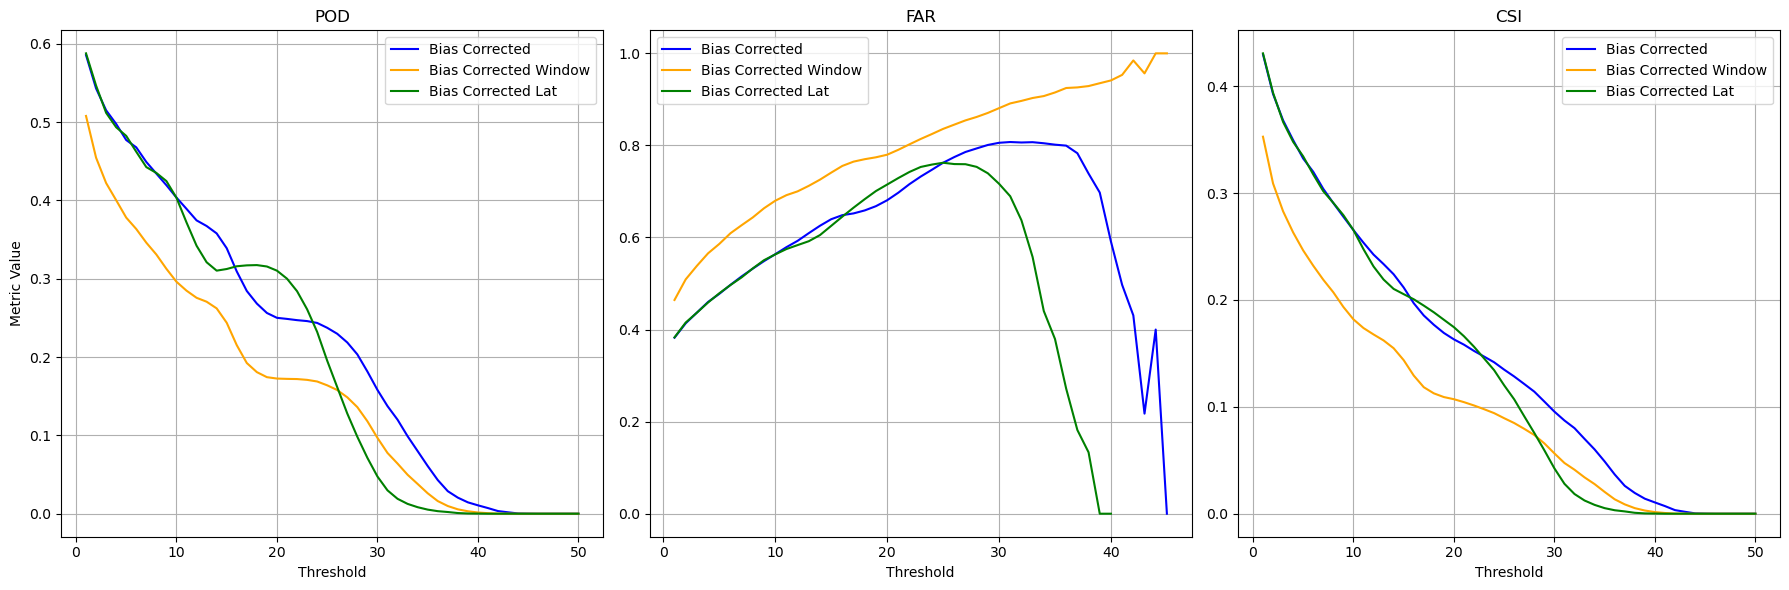

In [ ]:
# Define thresholds range
thresholds = np.arange(1, 51, 1)

# Initialize lists to store results
metrics_bias_corrected_list = []
metrics_bias_corrected_window_list = []
metrics_bias_corrected_lat_list = []

# Loop through each threshold
for threshold in thresholds:
    # Calculate metrics for bias_corrected_ascat_valid
    metrics_bias_corrected = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid.values.transpose(2, 0, 1),
        threshold
    )
    metrics_bias_corrected_list.append(metrics_bias_corrected)

    # Calculate metrics for bias_corrected_ascat_valid_window
    metrics_bias_corrected_window = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid_window['rainfall'].values.transpose(2, 0, 1),
        threshold
    )
    metrics_bias_corrected_window_list.append(metrics_bias_corrected_window)

    # Calculate metrics for bias_corrected_ascat_valid_lat
    metrics_bias_corrected_lat = process_precipitation_data(
        valid_datasets['IMERG_ASCAT'].values,
        bias_corrected_ascat_valid_lat.values.transpose(2, 0, 1),
        threshold
    )
    metrics_bias_corrected_lat_list.append(metrics_bias_corrected_lat)

# Convert results to DataFrame for easier plotting
metrics_df = pd.DataFrame(metrics_bias_corrected_list)
metrics_window_df = pd.DataFrame(metrics_bias_corrected_window_list)
metrics_lat_df = pd.DataFrame(metrics_bias_corrected_lat_list)

# Add thresholds to DataFrames
metrics_df['Threshold'] = thresholds
metrics_window_df['Threshold'] = thresholds
metrics_lat_df['Threshold'] = thresholds

# Plot the metrics
plt.figure(figsize=(18, 6))

# Plot POD
plt.subplot(1, 3, 1)
plt.plot(metrics_df['Threshold'], metrics_df['POD'], label="Bias Corrected", color="blue")
plt.plot(metrics_window_df['Threshold'], metrics_window_df['POD'], label="Bias Corrected Window", color="orange")
plt.plot(metrics_lat_df['Threshold'], metrics_lat_df['POD'], label="Bias Corrected Lat", color="green")
plt.title("POD")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.grid()

# Plot FAR
plt.subplot(1, 3, 2)
plt.plot(metrics_df['Threshold'], metrics_df['FAR'], label="Bias Corrected", color="blue")
plt.plot(metrics_window_df['Threshold'], metrics_window_df['FAR'], label="Bias Corrected Window", color="orange")
plt.plot(metrics_lat_df['Threshold'], metrics_lat_df['FAR'], label="Bias Corrected Lat", color="green")
plt.title("FAR")
plt.xlabel("Threshold")
plt.legend()
plt.grid()

# Plot CSI
plt.subplot(1, 3, 3)
plt.plot(metrics_df['Threshold'], metrics_df['CSI'], label="Bias Corrected", color="blue")
plt.plot(metrics_window_df['Threshold'], metrics_window_df['CSI'], label="Bias Corrected Window", color="orange")
plt.plot(metrics_lat_df['Threshold'], metrics_lat_df['CSI'], label="Bias Corrected Lat", color="green")
plt.title("CSI")
plt.xlabel("Threshold")
plt.legend()
plt.grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


## R, RMSE, PBIAS

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def calculate_metrics(observed, simulated):
    """
    Calculate R value, PBIAS, and RMSE between observed and simulated datasets.

    Parameters:
        observed (xarray.DataArray): Observed dataset.
        simulated (xarray.DataArray): Simulated dataset.

    Returns:
        dict: Dictionary containing R value, PBIAS, and RMSE.
    """
    # Flatten the data and exclude NaNs
    observed_flat = observed.values.flatten()
    simulated_flat = simulated.values.flatten()
    mask = ~np.isnan(observed_flat) & ~np.isnan(simulated_flat)
    observed_clean = observed_flat[mask]
    simulated_clean = simulated_flat[mask]

    # Calculate metrics
    r_value = np.corrcoef(observed_clean, simulated_clean)[0, 1]
    pbias = 100 * np.sum(simulated_clean - observed_clean) / np.sum(observed_clean)
    rmse = np.sqrt(mean_squared_error(observed_clean, simulated_clean))

    return {"R": r_value, "PBIAS": pbias, "RMSE": rmse}


In [ ]:

# Example usage
calculate_metrics(valid_datasets['IMERG_CCI'], valid_datasets['CCI'])


{'R': 0.5711687102726107,
 'PBIAS': 5.458149278903382,
 'RMSE': 5.491769027394024}

In [ ]:
bias_corrected_cci_valid.shape

(12, 16, 1826)

In [ ]:
valid_datasets['IMERG_CCI'].shape

(1826, 12, 16)

In [ ]:
calculate_metrics(valid_datasets['IMERG_CCI'], bias_corrected_cci_valid.transpose('time', 'lat', 'lon'))

{'R': 0.5275589561766396,
 'PBIAS': 21.77089421114118,
 'RMSE': 7.374321178764192}

In [ ]:
xr.corr(valid_datasets['IMERG_ASCAT'], bias_corrected_ascat_valid, dim = 'time').values.flatten()

array([nan, nan, nan, ..., nan, nan, nan])

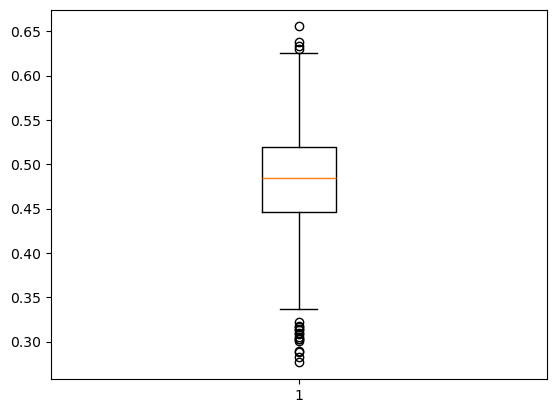

In [ ]:
r_values = xr.corr(valid_datasets['IMERG_ASCAT'], bias_corrected_ascat_valid, dim = 'time').values.flatten()
mask = ~np.isnan(r_values)
r_values = r_values[mask]
plt.figure()
plt.boxplot(r_values)
plt.show()